# Motivating Example: 2-TX Duke Scene

**Scene:** Duke — two transmitters, Zone 1 (partial LOS) and Zone 2 (NLOS-heavy)  
**Frequency:** 3.5 GHz

Four baselines, each revealing a distinct weakness that motivates the proposed method:

| # | Baseline | Category | Weakness Exposed |
|---|----------|----------|------------------|
| 1 | `naive_edge_center` | Geometric heuristic | Empirical ~= ray-traced coverage |
| 2 | `empirical_pso` | Gradient-free + empirical | Channel model blind to blockage |
| 3 | `radiomap_gradient` | First-order + RadioMap | Near-zero gradients (binning approx.) |
| 4 | `dense_pathsolver_gradient` | First-order + PathSolver dense | Exact grads but O(zone²) per step |

In [18]:
# ── CONFIGURATION ─────────────────────────────────────────────────────────────
SCENE_XML_PATH = "../scene/scenes/Duke/scene.xml"
CARRIER_HZ     = 3.5e9

# Iteration / sample budget (keep modest for the motivating example)
MOTIV_NUM_ITER       = 50
MOTIV_SAMPLES_PER_TX = int(1e7)

# ── TRANSMITTER 1 (same building as single-TX motivating example) ─────────────
TX1_NAME        = "gnb1"
TX1_BUILDING_ID = 12
TX1_HEIGHT_M    = 10.0

# ── TRANSMITTER 2 (NLOS-heavy zone on opposite side) ─────────────────────────
# NOTE: Confirm TX2_BUILDING_ID via the zone visualization cell below.
# Pick a building whose rooftop has sightlines partially blocked by surrounding
# buildings toward Zone 2 — makes the NLOS scenario visually clear.
TX2_NAME        = "gnb2"
TX2_BUILDING_ID = 9   # ← SET THIS after running the scene visualization
TX2_HEIGHT_M    = 10.0

# ── ZONE 1 (partial LOS — northwest quadrant) ─────────────────────────────────
ZONE1_CENTER   = [-200.0, 300.0]
ZONE1_WIDTH_M  = 400.0
ZONE1_HEIGHT_M = 400.0

# ── ZONE 2 (NLOS-heavy — southwest quadrant) ──────────────────────────────────
ZONE2_CENTER   = [-100.0, -100.0]
ZONE2_WIDTH_M  = 400.0
ZONE2_HEIGHT_M = 400.0

# ── RADIO MAP ─────────────────────────────────────────────────────────────────
MAP_CONFIG = {
    'center':        [0.0, 0.0, 0.0],
    'size':          [1400, 1400],
    'cell_size':     (5, 5),
    'ground_height': 0.0,
}

# ── EXPERIMENT ────────────────────────────────────────────────────────────────
NOISE_POWER = 1e-10
JITTER_SEED = 42
JITTER_MAG  = 1e-4

In [19]:
import sys, os
sys.path.append(os.path.abspath('../src'))
import warnings; warnings.filterwarnings("ignore")
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import mitsuba as mi

try:
    import sionna.rt
except ImportError:
    os.system("pip install sionna-rt")
    import sionna.rt

from sionna.rt import load_scene, AntennaArray
from sionna.rt.antenna_pattern import antenna_pattern_registry

from scene_parser import extract_building_info
from tx_placement import TxPlacement
from boresight_pathsolver import create_zone_mask
from angle_utils import compute_initial_angles_from_position, azimuth_elevation_to_yaw_pitch
from multi_tx_optimizer import TxConfig
from experiment_runner import (
    compare_all_results, plot_cdf, plot_metric_bars, plot_zone_overview,
)
from motivating_baselines import (
    naive_edge_center_baseline_multi_tx,
    empirical_pso_baseline_multi_tx,
    radiomap_gradient_baseline_multi_tx,
    dense_pathsolver_gradient_baseline_multi_tx,
)

scene = load_scene(SCENE_XML_PATH)
scene.frequency = CARRIER_HZ

single_el = np.array([[0.0, 0.0, 0.0]])
scene.tx_array = AntennaArray(
    antenna_pattern=antenna_pattern_registry.get("tr38901")(polarization="V"),
    normalized_positions=single_el.T,
)
scene.rx_array = AntennaArray(
    antenna_pattern=antenna_pattern_registry.get("iso")(polarization="V"),
    normalized_positions=single_el.T,
)
for rm in scene.radio_materials.values():
    rm.scattering_coefficient = 0.4

building_info = extract_building_info(SCENE_XML_PATH, verbose=False)
print(f"Scene loaded  |  {CARRIER_HZ/1e9:.1f} GHz  |  {len(building_info)} buildings")

2026-04-17 01:33:04 WARN  [HDRFilm] Monochrome mode enabled, setting film output pixel format to 'luminance' (was rgb).
Scene loaded  |  3.5 GHz  |  154 buildings


In [20]:
# ── ZONE MASKS ────────────────────────────────────────────────────────────────
zone_params1 = {'center': ZONE1_CENTER, 'width': ZONE1_WIDTH_M, 'height': ZONE1_HEIGHT_M}
zone_mask1, look_at1, zone_stats1 = create_zone_mask(
    map_config=MAP_CONFIG, zone_type='box', zone_params=zone_params1,
    target_height=1.5, scene_xml_path=SCENE_XML_PATH, exclude_buildings=True,
)

zone_params2 = {'center': ZONE2_CENTER, 'width': ZONE2_WIDTH_M, 'height': ZONE2_HEIGHT_M}
zone_mask2, look_at2, zone_stats2 = create_zone_mask(
    map_config=MAP_CONFIG, zone_type='box', zone_params=zone_params2,
    target_height=1.5, scene_xml_path=SCENE_XML_PATH, exclude_buildings=True,
)

print(f"Zone 1 (NW): {zone_stats1['num_cells']:6d} cells  centroid={[round(v,1) for v in zone_stats1['centroid_xy']]}")
print(f"Zone 2 (SW): {zone_stats2['num_cells']:6d} cells  centroid={[round(v,1) for v in zone_stats2['centroid_xy']]}")

Zone 1 (NW):   4267 cells  centroid=[-197.8, 303.3]
Zone 2 (SW):   4712 cells  centroid=[-108.0, -99.4]


In [21]:
# ── TX PLACEMENTS ─────────────────────────────────────────────────────────────
tx_placer1 = TxPlacement(scene, TX1_NAME, SCENE_XML_PATH, TX1_BUILDING_ID, offset=TX1_HEIGHT_M)
tx_placer1.set_rooftop_center()
tx1     = scene.get(TX1_NAME)
tx1_pos = tx1.position.numpy().flatten().tolist()
print(f"TX1 on building {TX1_BUILDING_ID} at ({tx1_pos[0]:.2f}, {tx1_pos[1]:.2f}, {tx1_pos[2]:.2f})")

assert TX2_BUILDING_ID is not None, "Set TX2_BUILDING_ID in the config cell first!"
tx_placer2 = TxPlacement(scene, TX2_NAME, SCENE_XML_PATH, TX2_BUILDING_ID, offset=TX2_HEIGHT_M)
tx_placer2.set_rooftop_center()
tx2     = scene.get(TX2_NAME)
tx2_pos = tx2.position.numpy().flatten().tolist()
print(f"TX2 on building {TX2_BUILDING_ID} at ({tx2_pos[0]:.2f}, {tx2_pos[1]:.2f}, {tx2_pos[2]:.2f})")

TX1 on building 12 at (-10.85, 329.46, 27.50)
TX2 on building 9 at (-272.42, -63.06, 27.50)


In [22]:
# ── INITIAL JITTER ────────────────────────────────────────────────────────────
rng = np.random.default_rng(JITTER_SEED)

def _jitter_tx(tx_obj, tx_pos, zone_stats, rng):
    base_az, base_el = compute_initial_angles_from_position(tx_pos, zone_stats["look_at_xyz"])
    az  = base_az + float(rng.uniform(-JITTER_MAG, JITTER_MAG))
    el  = base_el + float(rng.uniform(-JITTER_MAG, JITTER_MAG))
    yaw, pitch = azimuth_elevation_to_yaw_pitch(az, el)
    tx_obj.orientation = [float(yaw), float(pitch), 0.0]
    return az, el, yaw, pitch

az1, el1, yaw1, pitch1 = _jitter_tx(tx1, tx1_pos, zone_stats1, rng)
az2, el2, yaw2, pitch2 = _jitter_tx(tx2, tx2_pos, zone_stats2, rng)

# Store initial state for restoration between baselines
_init = {
    TX1_NAME: (tx1_pos[:], yaw1, pitch1),
    TX2_NAME: (tx2_pos[:], yaw2, pitch2),
}

def _restore_both_tx():
    """Reset both TXs to their jittered initial state before each baseline."""
    for name, (pos, yaw, pitch) in _init.items():
        tx = scene.get(name)
        tx.position    = mi.Point3f(float(pos[0]), float(pos[1]), float(pos[2]))
        tx.orientation = mi.Point3f(float(yaw), float(pitch), 0.0)

print(f"TX1  Az={az1:.6f}°  El={el1:.6f}°")
print(f"TX2  Az={az2:.6f}°  El={el2:.6f}°")

Tx Position: [-10.852537155151367, 329.458984375, 27.5]
look_at_position: [-200.0, 300.0, 1.5]
Tx Position: [-272.4181213378906, -63.0598030090332, 27.5]
look_at_position: [-100.0, -100.0, 1.5]
TX1  Az=188.852530°  El=-7.734679°
TX2  Az=347.907394°  El=-8.387786°


# ── ZONE + TX VISUALIZATION ───────────────────────────────────────────────────
zone_entries = [
    dict(mask=zone_mask1, cmap='Blues', color='steelblue',
         tx_pos=tx1_pos, tx_name=TX1_NAME, building_id=TX1_BUILDING_ID,
         centroid_xy=zone_stats1['centroid_xy'], zone_label='Zone 1 centroid', marker='^'),
    dict(mask=zone_mask2, cmap='Oranges', color='darkorange',
         tx_pos=tx2_pos, tx_name=TX2_NAME, building_id=TX2_BUILDING_ID,
         centroid_xy=zone_stats2['centroid_xy'], zone_label='Zone 2 centroid', marker='s'),
]
plot_zone_overview(
    building_info, MAP_CONFIG, zone_entries,
    title='Duke Motivating Example — Zone 1 (blue, NW) | Zone 2 (orange, SW)',
    figsize=(9, 9),
)

In [23]:
# ── TX CONFIGS ────────────────────────────────────────────────────────────────
tx_configs_2 = [
    TxConfig(name=TX1_NAME, building_id=TX1_BUILDING_ID,
             zone_params=zone_params1, tx_height_offset=TX1_HEIGHT_M,
             num_sample_points=128),
    TxConfig(name=TX2_NAME, building_id=TX2_BUILDING_ID,
             zone_params=zone_params2, tx_height_offset=TX2_HEIGHT_M,
             num_sample_points=128),
]
motiv_results = {}

## Baseline 1 — Naive Edge-Center
Places each TX on the building edge facing its zone centroid and aims geometrically.  
Runs both a 3GPP UMa empirical evaluation and a Sionna ray-traced evaluation to expose the gap.

In [24]:
_restore_both_tx()

result_edge = naive_edge_center_baseline_multi_tx(
    scene=scene,
    tx_configs=tx_configs_2,
    map_config=MAP_CONFIG,
    scene_xml_path=SCENE_XML_PATH,
    noise_power=NOISE_POWER,
    frequency_hz=CARRIER_HZ,
    verbose=True,
)
motiv_results["naive_edge_center"] = result_edge

print(f"\nEmpirical loss : {result_edge['joint']['empirical_loss']:.4f}")
print(f"Ray-traced loss: {result_edge['joint']['raytraced_loss']:.4f}")
print(f"Gap (Δ)        : {result_edge['joint']['raytraced_loss'] - result_edge['joint']['empirical_loss']:+.4f}")


NAIVE EDGE-CENTER BASELINE  (2 TX)


Tx Position: [-10.852537155151367, 329.458984375, 27.5]
look_at_position: [-200.0, 300.0, 1.5]
Tx Position: [-272.4181213378906, -63.0598030090332, 27.5]
look_at_position: [-100.0, -100.0, 1.5]
Tx Position: [-64.0728988647461, 327.0882873535156, 27.5]
look_at_position: [-200.92015582651473, 298.7425092424662, 1.5]
  gnb1: Az=191.7°  El=-10.5°  pos=(-64.1, 327.1)
Tx Position: [-228.77723693847656, -45.58987045288086, 27.5]
look_at_position: [-108.32971172169319, -99.12321014780282, 1.5]
  gnb2: Az=336.0°  El=-11.2°  pos=(-228.8, -45.6)

  Ray-traced loss : -0.9577
  Empirical loss  : -0.9581  (2.5s)


Empirical loss : -0.9581
Ray-traced loss: -0.9577
Gap (Δ)        : +0.0004


## Baseline 2 — Empirical PSO (3GPP UMa)
PSO driven by the UMa channel model — no ray tracing, no geometric scene knowledge.  
Shows that the empirical model cannot distinguish LOS from NLOS blockage.

In [25]:
_restore_both_tx()

result_emp_pso = empirical_pso_baseline_multi_tx(
    scene=scene,
    tx_configs=tx_configs_2,
    map_config=MAP_CONFIG,
    scene_xml_path=SCENE_XML_PATH,
    noise_power=NOISE_POWER,
    frequency_hz=CARRIER_HZ,
    n_particles=20,
    num_iterations=30,
    seed=42,
    verbose=True,
)
motiv_results["empirical_pso"] = result_emp_pso


EMPIRICAL PSO BASELINE  (20 particles × 30 iters, 2 TX)
  Channel model: 3GPP TR 38.901 UMa (no ray tracing)
Tx Position: [-10.852537155151367, 329.458984375, 27.5]
look_at_position: [-200.0, 300.0, 1.5]


Tx Position: [-272.4181213378906, -63.0598030090332, 27.5]
look_at_position: [-100.0, -100.0, 1.5]
  Iter   1/30  global_best=-0.9350  (0.0s)
  Iter   2/30  global_best=-0.9499  (0.0s)
  Iter   3/30  global_best=-0.9533  (0.0s)
  Iter   4/30  global_best=-0.9618  (0.0s)
  Iter   5/30  global_best=-0.9618  (0.0s)
  Iter   6/30  global_best=-0.9632  (0.0s)
  Iter   7/30  global_best=-0.9632  (0.0s)
  Iter   8/30  global_best=-0.9640  (0.0s)
  Iter   9/30  global_best=-0.9642  (0.0s)
  Iter  10/30  global_best=-0.9648  (0.0s)
  Iter  11/30  global_best=-0.9657  (0.0s)
  Iter  12/30  global_best=-0.9657  (0.0s)
  Iter  13/30  global_best=-0.9657  (0.0s)
  Iter  14/30  global_best=-0.9657  (0.0s)
  [early stop] no improvement over last 5 iters at iter 14

  Best loss (empirical): -0.9657  (0.6s)
  gnb1: Az=186.2°  El=-6.2°  pos=(-12.4, 323.9)
  gnb2: Az=0.0°  El=-8.8°  pos=(-293.3, -94.5)



## Baseline 3 — RadioMap Gradient (Adam)
First-order optimization via `RadioMapSolver`.  Gradient norms are expected to be near-zero due to solid-angle ray-tube binning — signal at a cell only changes when a ray crosses a bin boundary, producing piecewise-constant gradients.


RADIOMAP GRADIENT BASELINE  (2 TX, 50 iters, lr=1.2)
  Logging grad norms + post-convergence dual evaluation


Tx Position: [-10.852537155151367, 329.458984375, 27.5]
look_at_position: [-200.0, 300.0, 1.5]
Tx Position: [-272.4181213378906, -63.0598030090332, 27.5]
look_at_position: [-100.0, -100.0, 1.5]
  Iter   1/50  loss=1.9729  |∇|=7.42e-03  (10.9s)
  Iter   2/50  loss=1.9896  |∇|=6.28e-03  (6.7s)
  Iter   3/50  loss=1.8819  |∇|=5.51e-03  (1.4s)
  Iter   4/50  loss=1.8393  |∇|=4.94e-03  (1.4s)
  Iter   5/50  loss=1.9245  |∇|=4.24e-03  (1.4s)
  Iter   6/50  loss=1.7382  |∇|=3.45e-03  (1.4s)
  Iter   7/50  loss=1.8297  |∇|=2.77e-03  (1.4s)
  Iter   8/50  loss=1.8307  |∇|=2.01e-03  (1.4s)
  Iter   9/50  loss=1.7444  |∇|=1.34e-03  (1.4s)
  Iter  10/50  loss=1.7472  |∇|=7.39e-04  (1.4s)
  Iter  11/50  loss=1.6072  |∇|=2.41e-04  (1.4s)
  Iter  12/50  loss=1.7686  |∇|=7.55e-04  (1.4s)
  Iter  13/50  loss=1.7954  |∇|=1.14e-03  (1.4s)
  Iter  14/50  loss=1.9248  |∇|=1.53e-03  (1.4s)
  [early stop] oscillating at iter 14 (5 sign flips, net Δloss=0.0003)

RADIOMAP GRADIENT BASELINE COMPLETE  (36.9s)
  

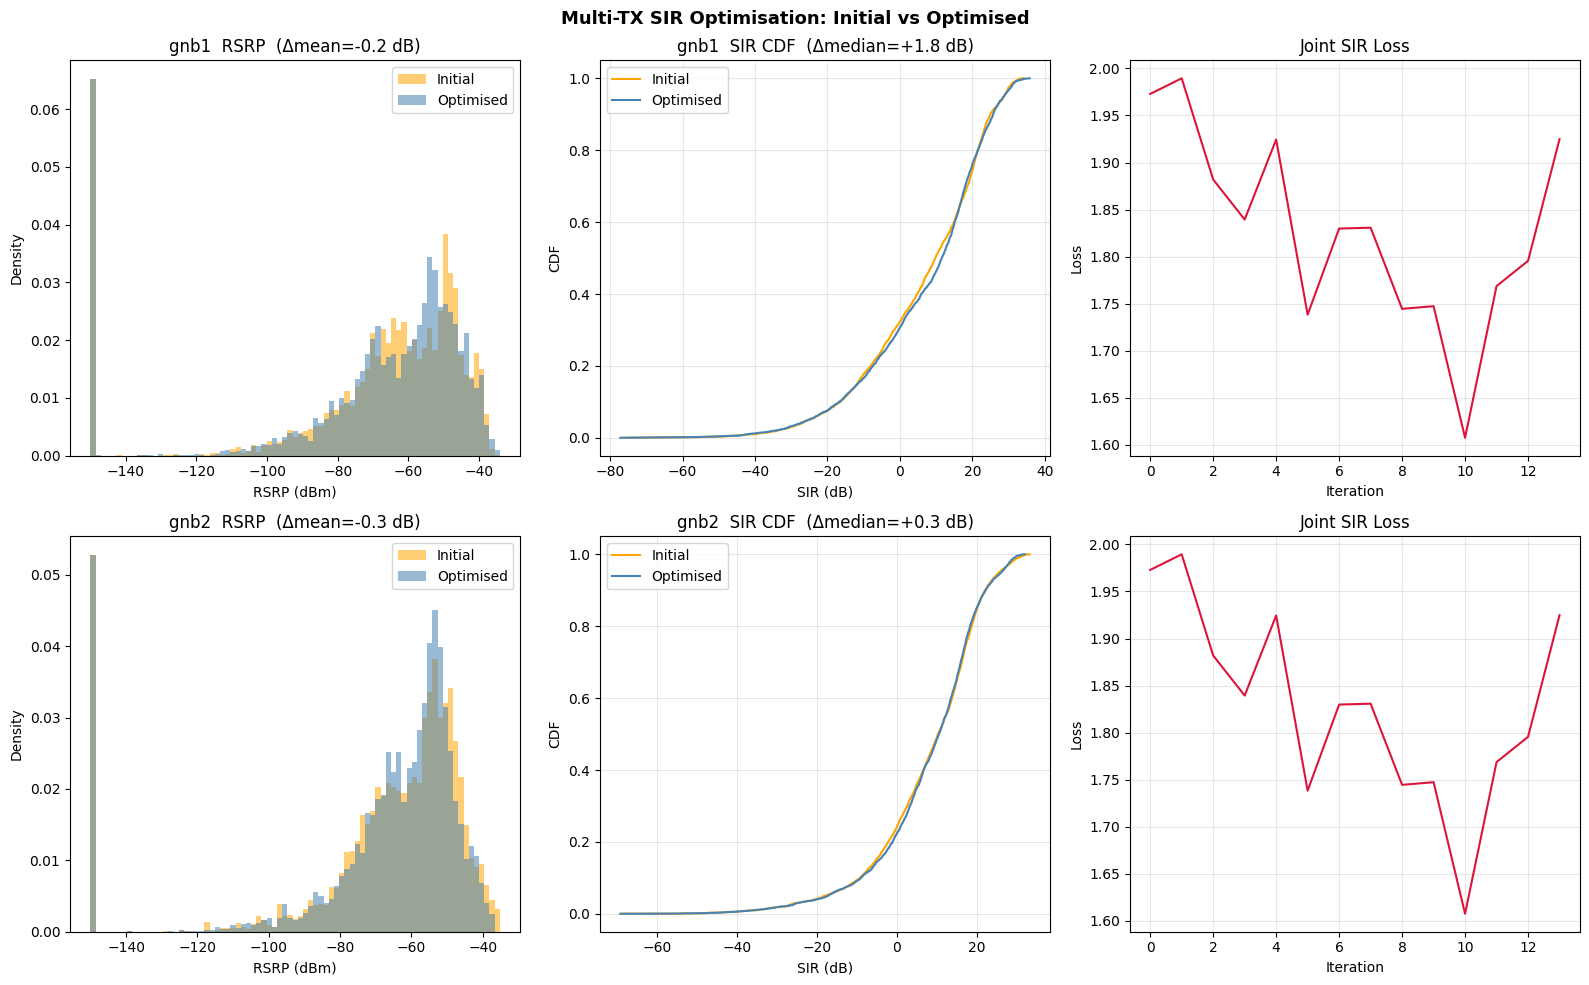

In [26]:
from multi_tx_optimizer import compare_multi_tx_performance

_restore_both_tx()

result_rm_grad = radiomap_gradient_baseline_multi_tx(
    scene=scene,
    tx_configs=tx_configs_2,
    map_config=MAP_CONFIG,
    scene_xml_path=SCENE_XML_PATH,
    noise_power=NOISE_POWER,
    frequency_hz=CARRIER_HZ,
    learning_rate=1.2,
    num_iterations=MOTIV_NUM_ITER,
    samples_per_tx=MOTIV_SAMPLES_PER_TX,
    n_empirical_pts=500,
    verbose=True,
)
motiv_results["radiomap_gradient"] = result_rm_grad

print(f"\nGrad norm  — mean: {float(np.mean(result_rm_grad['joint']['grad_norm_history'])):.2e}"
      f"  min: {float(np.min(result_rm_grad['joint']['grad_norm_history'])):.2e}"
      f"  max: {float(np.max(result_rm_grad['joint']['grad_norm_history'])):.2e}")

_restore_both_tx()   # reset scene to initial state first

fig, stats = compare_multi_tx_performance(
    scene       = scene,
    tx_configs  = tx_configs_2,
    multi_result= motiv_results["radiomap_gradient"],  # or any other result dict
    map_config  = MAP_CONFIG,
    zone_masks  = [zone_mask1, zone_mask2],            # list is fine now
    noise_power = NOISE_POWER,
    samples_per_tx = int(1e7),                         # fast for motivating figure
)


## Baseline 4 — Dense PathSolver Gradient (Adam)
First-order optimization via PathSolver over a full dense receiver grid.  Gradient magnitudes should be significantly larger than Baseline 3, but per-iteration time scales as O(zone²/spacing²).

In [27]:
_restore_both_tx()

result_dense = dense_pathsolver_gradient_baseline_multi_tx(
    scene=scene,
    tx_configs=tx_configs_2,
    map_config=MAP_CONFIG,
    scene_xml_path=SCENE_XML_PATH,
    noise_power=NOISE_POWER,
    learning_rate=3.5,
    num_iterations=MOTIV_NUM_ITER,
    verbose=True,
)
motiv_results["dense_pathsolver"] = result_dense

print(f"\nReceivers used : {result_dense['joint']['n_receivers']}")
print(f"Grad norm      — mean: {float(np.mean(result_dense['joint']['grad_norm_history'])):.2e}"
      f"  min: {float(np.min(result_dense['joint']['grad_norm_history'])):.2e}"
      f"  max: {float(np.max(result_dense['joint']['grad_norm_history'])):.2e}")
print(f"Mean iter time : {float(np.mean(result_dense['joint']['iter_time_history'])):.1f}s")


DENSE PATHSOLVER BASELINE  (2 TX, 50 iters, lr=3.5, grid=5m)
Tx Position: [-10.852537155151367, 329.458984375, 27.5]
look_at_position: [-200.0, 300.0, 1.5]


Tx Position: [-272.4181213378906, -63.0598030090332, 27.5]
look_at_position: [-100.0, -100.0, 1.5]
  Zone gnb1: 4386 receivers (5 m grid)
  Zone gnb2: 4718 receivers (5 m grid)
  Total receivers: 9104
  Iter   1/50  loss=-0.8781  |∇|=2.85e-05  (30.8s)
  Iter   2/50  loss=-0.8777  |∇|=2.12e-05  (7.4s)
  Iter   3/50  loss=-0.8773  |∇|=1.80e-05  (5.4s)
  Iter   4/50  loss=-0.8772  |∇|=2.08e-05  (5.0s)
  Iter   5/50  loss=-0.8770  |∇|=2.07e-05  (6.3s)
  Iter   6/50  loss=-0.8772  |∇|=1.99e-05  (4.8s)
  Iter   7/50  loss=-0.8775  |∇|=1.94e-05  (4.7s)
  Iter   8/50  loss=-0.8788  |∇|=1.72e-05  (4.7s)
  Iter   9/50  loss=-0.8782  |∇|=1.84e-05  (4.8s)
  Iter  10/50  loss=-0.8771  |∇|=1.63e-05  (4.7s)
  Iter  11/50  loss=-0.8774  |∇|=1.34e-05  (4.8s)
  Iter  12/50  loss=-0.8769  |∇|=1.19e-05  (4.8s)
  Iter  13/50  loss=-0.8771  |∇|=1.78e-05  (4.7s)
  Iter  14/50  loss=-0.8768  |∇|=1.49e-05  (4.8s)
  Iter  15/50  loss=-0.8767  |∇|=1.40e-05  (4.8s)
  Iter  16/50  loss=-0.8770  |∇|=1.32e-05  (4.8s

## Summary

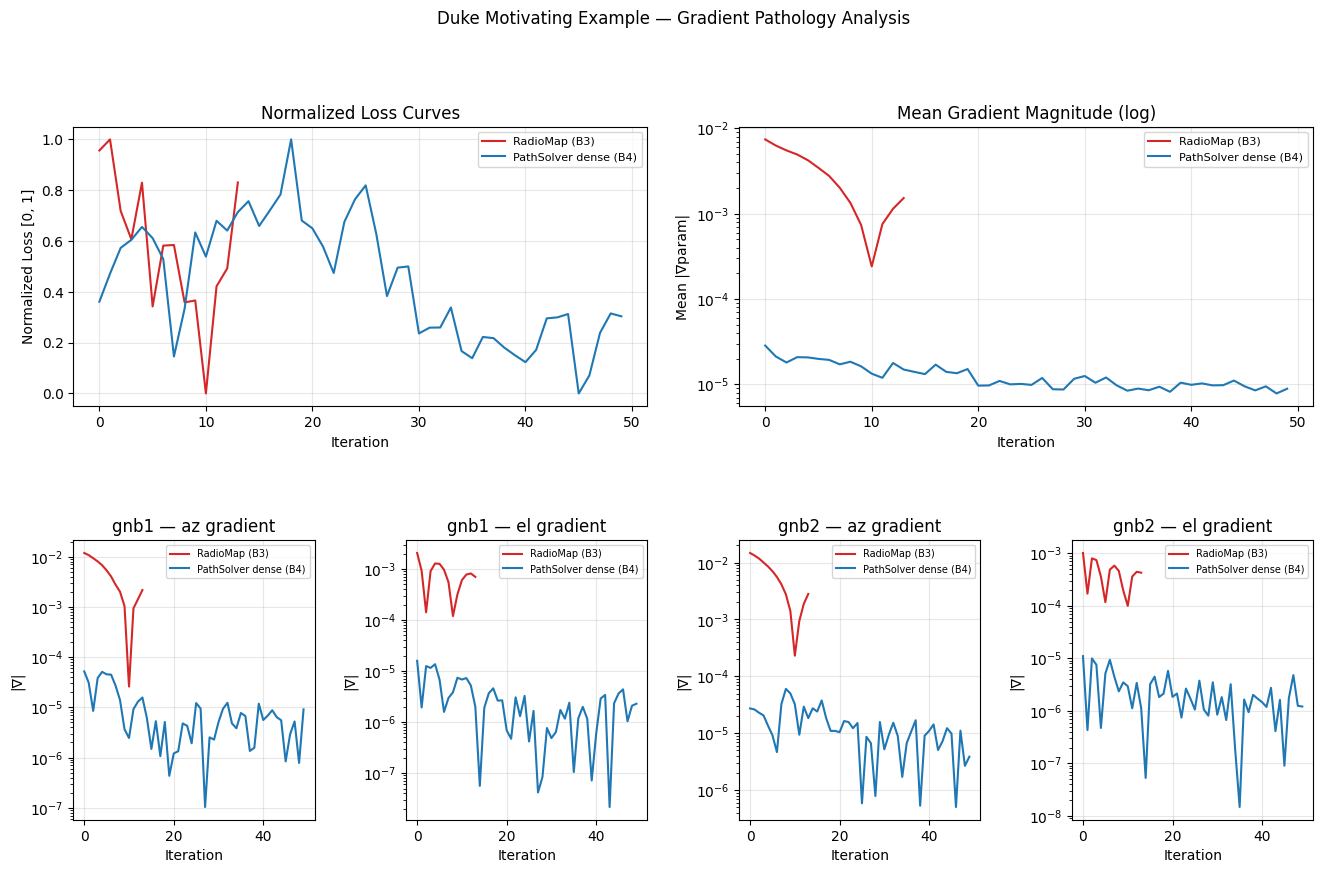

In [28]:
# ── GRAD PATHOLOGY ANALYSIS (Baselines 3 vs 4) ────────────────────────────────
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(16, 9))
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.48, wspace=0.38)

_methods = [
    ("RadioMap (B3)",         result_rm_grad, "tab:red"),
    ("PathSolver dense (B4)", result_dense,   "tab:blue"),
]

# ── Row 0: normalized loss | mean grad norm ───────────────────────────────────
ax_loss  = fig.add_subplot(gs[0, :2])
ax_gnorm = fig.add_subplot(gs[0, 2:])

for label, res, color in _methods:
    hist = np.array(res['joint']['loss_history'], dtype=float)
    lo, hi = hist.min(), hist.max()
    norm_hist = (hist - lo) / (hi - lo) if hi > lo else np.zeros_like(hist)
    ax_loss.plot(norm_hist, label=label, color=color, linewidth=1.5)

    ax_gnorm.plot(res['joint']['grad_norm_history'], label=label, color=color, linewidth=1.5)

ax_loss.set_xlabel('Iteration')
ax_loss.set_ylabel('Normalized Loss [0, 1]')
ax_loss.set_title('Normalized Loss Curves')
ax_loss.legend(fontsize=8)
ax_loss.grid(True, alpha=0.3)

ax_gnorm.set_xlabel('Iteration')
ax_gnorm.set_ylabel('Mean |∇param|')
ax_gnorm.set_title('Mean Gradient Magnitude (log)')
ax_gnorm.set_yscale('log')
ax_gnorm.legend(fontsize=8)
ax_gnorm.grid(True, alpha=0.3)

# ── Row 1: per-param gradients (az, el) for each TX ──────────────────────────
_tx_names   = [TX1_NAME, TX2_NAME]
_param_keys = ["az", "el"]

for tx_i, tx_name in enumerate(_tx_names):
    for p_i, pname in enumerate(_param_keys):
        ax = fig.add_subplot(gs[1, tx_i * 2 + p_i])
        for label, res, color in _methods:
            pgh  = res['joint'].get('param_grad_histories', {})
            vals = pgh.get(tx_name, {}).get(pname)
            if vals:
                ax.plot(vals, label=label, color=color, linewidth=1.5)
        ax.set_xlabel('Iteration')
        ax.set_ylabel('|∇|')
        ax.set_title(f'{tx_name} — {pname} gradient')
        ax.set_yscale('log')
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)

plt.suptitle('Duke Motivating Example — Gradient Pathology Analysis', y=1.01)
plt.show()

RadioMap (B3)                   mean cos=+0.894  median=+0.996  frac<0=0.00%
PathSolver dense (B4)           mean cos=+0.935  median=+0.972  frac<0=0.00%


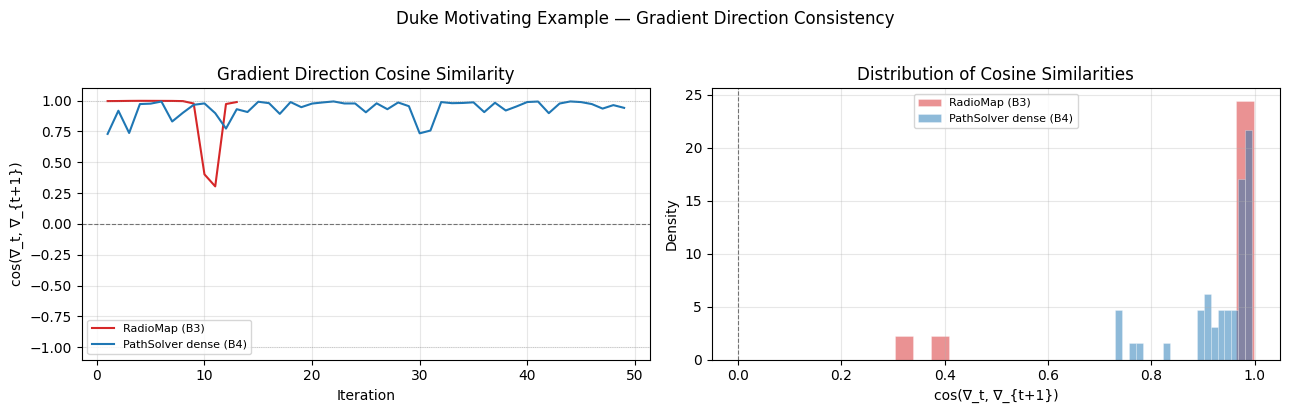

In [29]:
# ── GRADIENT COSINE SIMILARITY (Baselines 3 vs 4) ─────────────────────────────
# cos(∇_t, ∇_{t+1}) near +1 → consistent descent direction (good)
# cos(∇_t, ∇_{t+1}) near -1 → gradient direction-flipping (explains oscillation)

def _cosine_similarities(grad_vecs):
    sims = []
    for t in range(1, len(grad_vecs)):
        a = np.array(grad_vecs[t - 1], dtype=float)
        b = np.array(grad_vecs[t],     dtype=float)
        na, nb = np.linalg.norm(a), np.linalg.norm(b)
        sims.append(float(np.dot(a, b) / (na * nb)) if na > 0 and nb > 0 else 0.0)
    return sims

_methods = [
    ("RadioMap (B3)",         result_rm_grad, "tab:red"),
    ("PathSolver dense (B4)", result_dense,   "tab:blue"),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax_cos  = axes[0]
ax_hist = axes[1]

for label, res, color in _methods:
    gvh  = res['joint'].get('grad_vector_history', [])
    sims = _cosine_similarities(gvh)
    xs   = list(range(1, len(sims) + 1))

    ax_cos.plot(xs, sims, label=label, color=color, linewidth=1.5)
    ax_hist.hist(sims, bins=20, alpha=0.5, label=label, color=color,
                 density=True, edgecolor='white', linewidth=0.4)

ax_cos.axhline(0,  color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax_cos.axhline(1,  color='grey',  linewidth=0.6, linestyle=':',  alpha=0.4)
ax_cos.axhline(-1, color='grey',  linewidth=0.6, linestyle=':',  alpha=0.4)
ax_cos.set_xlabel('Iteration')
ax_cos.set_ylabel('cos(∇_t, ∇_{t+1})')
ax_cos.set_title('Gradient Direction Cosine Similarity')
ax_cos.set_ylim(-1.1, 1.1)
ax_cos.legend(fontsize=8)
ax_cos.grid(True, alpha=0.3)

ax_hist.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax_hist.set_xlabel('cos(∇_t, ∇_{t+1})')
ax_hist.set_ylabel('Density')
ax_hist.set_title('Distribution of Cosine Similarities')
ax_hist.legend(fontsize=8)
ax_hist.grid(True, alpha=0.3)

# Print summary stats
for label, res, _ in _methods:
    gvh  = res['joint'].get('grad_vector_history', [])
    sims = _cosine_similarities(gvh)
    if sims:
        print(f"{label:30s}  mean cos={np.mean(sims):+.3f}  "
              f"median={np.median(sims):+.3f}  "
              f"frac<0={np.mean(np.array(sims) < 0):.2%}")

plt.suptitle('Duke Motivating Example — Gradient Direction Consistency', y=1.02)
plt.tight_layout()
plt.show()


BEFORE / AFTER COMPARISON
  gnb1:
    Initial:   Az=188.9°, El=-7.7°, pos=(-10.9, 329.5)
    Optimised: Az=186.2°, El=-6.2°, pos=(-12.4, 323.9)
  gnb2:
    Initial:   Az=347.9°, El=-8.4°, pos=(-272.4, -63.1)
    Optimised: Az=0.0°, El=-8.8°, pos=(-293.3, -94.5)

Computing RadioMap for initial configuration...
Computing RadioMap for optimized configuration...

RESULTS
  gnb1  (4267 non-building zone cells):
    Coverage:      90.4%  →   90.8%  (+0.4 pp)
    RSRP mean:     -69.7 dBm  →    -69.1 dBm  (+0.5 dB)
    RSRP median:   -61.6 dBm  →    -61.4 dBm  (+0.2 dB)
    RSRP p10:     -110.5 dBm  →   -107.6 dBm  (+2.9 dB)
    RSRP p90:      -44.3 dBm  →    -44.3 dBm
    SIR mean:       +6.6 dB   →     +6.4 dB   (-0.2 dB)  [covered cells]
    SIR median:     +9.8 dB   →     +9.3 dB   (-0.5 dB)  [covered cells]
    SIR p10:       -16.3 dB   →    -16.9 dB   (-0.5 dB)  [covered cells]
    SIR p90:       +25.0 dB   →    +24.8 dB   [covered cells]
  gnb2  (4712 non-building zone cells):
    Cove

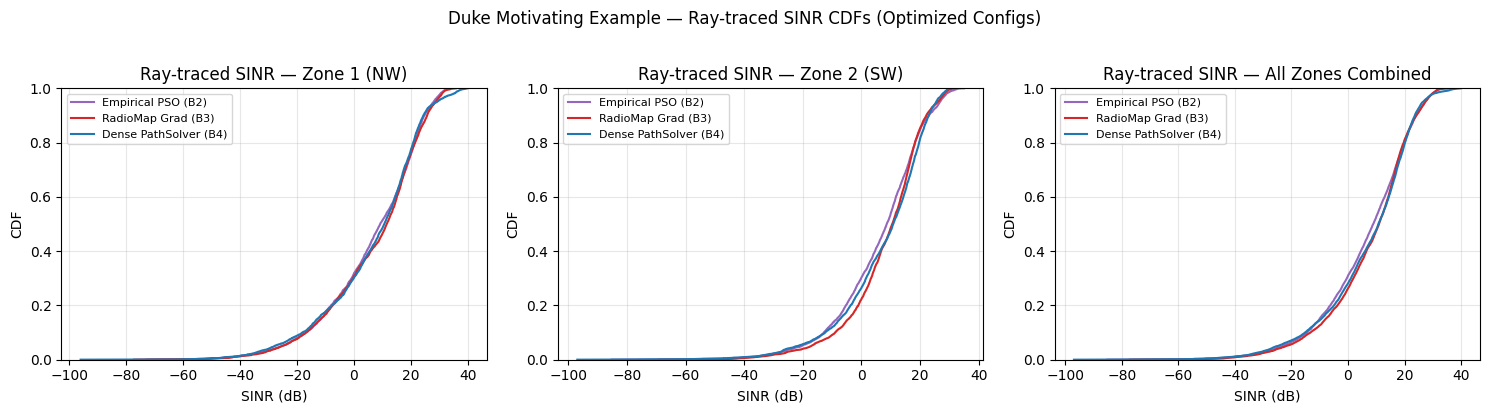

In [30]:
# ── RAY-TRACED SINR CDFs (Baselines 2, 3, 4) ──────────────────────────────────
# Runs RadioMapSolver on each method's final configuration to get per-cell SINR
# arrays for CDF comparison across the three gradient/zeroth-order baselines.

_sinr_entries = [
    ("Empirical PSO (B2)",    result_emp_pso, "tab:purple"),
    ("RadioMap Grad (B3)",    result_rm_grad,  "tab:red"),
    ("Dense PathSolver (B4)", result_dense,    "tab:blue"),
]

_sinr_stats = {}
for _label, _result, _color in _sinr_entries:
    _, _stats = compare_multi_tx_performance(
        scene=scene,
        tx_configs=tx_configs_2,
        multi_result=_result,
        map_config=MAP_CONFIG,
        zone_masks=[zone_mask1, zone_mask2],
        noise_power=NOISE_POWER,
        samples_per_tx=int(1e7),
        fig=False,
    )
    _sinr_stats[_label] = (_stats, _color)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
_zone_specs = [
    (TX1_NAME, "Zone 1 (NW)"),
    (TX2_NAME, "Zone 2 (SW)"),
    (None,     "All Zones Combined"),
]

for ax_i, (tx_name, zone_label) in enumerate(_zone_specs):
    ax = axes[ax_i]
    for _label, (_stats, _color) in _sinr_stats.items():
        if tx_name is not None:
            sinr_vals = np.array(_stats[tx_name]["optimized"]["sir_values_db"])
        else:
            sinr_vals = np.concatenate([
                np.array(_stats[TX1_NAME]["optimized"]["sir_values_db"]),
                np.array(_stats[TX2_NAME]["optimized"]["sir_values_db"]),
            ])
        sorted_v = np.sort(sinr_vals)
        cdf = np.arange(1, len(sorted_v) + 1) / len(sorted_v)
        ax.plot(sorted_v, cdf, label=_label, color=_color, linewidth=1.5)
    ax.set_xlabel("SINR (dB)")
    ax.set_ylabel("CDF")
    ax.set_title(f"Ray-traced SINR — {zone_label}")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1)

plt.suptitle("Duke Motivating Example — Ray-traced SINR CDFs (Optimized Configs)", y=1.02)
plt.tight_layout()
plt.show()

## Scaling Experiment — Sample Count vs. Convergence Speed

Compares six methods with position included in the optimization parameter set alongside azimuth/elevation.
Dense PathSolver variants span three grid resolutions (10 m → 2.5 m); triangulated SGD uses 75 stochastic samples per zone per iteration.
The goal is to show that keeping the sample count low (SGD regime) matches or exceeds the convergence quality of the dense grid at a fraction of the per-iteration cost.

In [33]:
# ── SCALING EXPERIMENT — SECTOR MAP CONFIGS + ZONE MASKS ──────────────────────
# Each dense solver run uses a MAP_CONFIG whose cell_size matches grid_spacing,
# so stride=1: every zone-mask cell becomes exactly one receiver.

_sector_map_configs = {
    "10m":  {**MAP_CONFIG, 'cell_size': (10.0, 10.0)},
    "5m":   MAP_CONFIG,                                    # already computed at startup
    "2.5m": {**MAP_CONFIG, 'cell_size': (2.5,  2.5)},
}

_zone_masks_by_sector = {"5m": (zone_mask1, zone_mask2)}

for _sz in ["10m", "2.5m"]:
    _mc = _sector_map_configs[_sz]
    _zm1, _, _zs1 = create_zone_mask(
        map_config=_mc, zone_type='box', zone_params=zone_params1,
        target_height=1.5, scene_xml_path=SCENE_XML_PATH, exclude_buildings=True,
    )
    _zm2, _, _zs2 = create_zone_mask(
        map_config=_mc, zone_type='box', zone_params=zone_params2,
        target_height=1.5, scene_xml_path=SCENE_XML_PATH, exclude_buildings=True,
    )
    _zone_masks_by_sector[_sz] = (_zm1, _zm2)
    print(f"  {_sz:>5}  Zone1={_zs1['num_cells']:7d} cells  Zone2={_zs2['num_cells']:7d} cells")

# TX configs for triangulated SGD with 150 sample points per zone
_tx_configs_scale = [
    TxConfig(name=TX1_NAME, building_id=TX1_BUILDING_ID,
             zone_params=zone_params1, tx_height_offset=TX1_HEIGHT_M,
             num_sample_points=150),
    TxConfig(name=TX2_NAME, building_id=TX2_BUILDING_ID,
             zone_params=zone_params2, tx_height_offset=TX2_HEIGHT_M,
             num_sample_points=150),
]
print("\nSector configs and zone masks ready.")

    10m  Zone1=   1070 cells  Zone2=   1170 cells
   2.5m  Zone1=  17048 cells  Zone2=  18791 cells

Sector configs and zone masks ready.


In [34]:
# ── SCALING EXPERIMENT — RUN ALL METHODS ──────────────────────────────────────
from multi_tx_optimizer import optimize_multi_tx

def _print_position_check(result, tx_configs):
    for cfg in tx_configs:
        r  = result[cfg.name]
        x0, y0 = r["initial_position"][0], r["initial_position"][1]
        xf, yf = r["final_position"][0],   r["final_position"][1]
        dx, dy = xf - x0, yf - y0
        print(f"    {cfg.name}  init=({x0:.1f}, {y0:.1f})  "
              f"final=({xf:.1f}, {yf:.1f})  Δ=({dx:+.1f}, {dy:+.1f})")

scaling_results = {}

# PSO — reuse already-computed result (gradient-free, empirical channel model)
scaling_results["pso"] = result_emp_pso

# Dense PathSolver at each grid spacing — position + orientation jointly optimised
for _sz, _spacing in [("10m", 10.0), ("5m", 5.0), ("2.5m", 2.5)]:
    print(f"\n{'─'*56}")
    print(f"  Dense PathSolver  grid={_sz}")
    print(f"{'─'*56}")
    _restore_both_tx()
    _result = dense_pathsolver_gradient_baseline_multi_tx(
        scene=scene,
        tx_configs=tx_configs_2,
        map_config=_sector_map_configs[_sz],
        scene_xml_path=SCENE_XML_PATH,
        noise_power=NOISE_POWER,
        learning_rate=3.5,
        num_iterations=MOTIV_NUM_ITER,
        grid_spacing=_spacing,
        verbose=True,
    )
    scaling_results[f"dense_{_sz}"] = _result
    print(f"  Position check (dense {_sz}):")
    _print_position_check(_result, tx_configs_2)

# Triangulated SGD — 150 stochastic sample points per zone per iteration
print(f"\n{'─'*56}")
print(f"  Triangulated SGD  (150 pts / zone)")
print(f"{'─'*56}")
_restore_both_tx()
_result_tri = optimize_multi_tx(
    scene=scene,
    tx_configs=_tx_configs_scale,
    map_config=MAP_CONFIG,
    scene_xml_path=SCENE_XML_PATH,
    noise_power=NOISE_POWER,
    learning_rate=3.5,
    num_iterations=MOTIV_NUM_ITER,
    sampler="triangulated",
    sampling_strata="full",
    verbose=True,
)
scaling_results["triangulated_150"] = _result_tri
print(f"  Position check (triangulated SGD):")
_print_position_check(_result_tri, _tx_configs_scale)

print("\nAll scaling runs complete.")
print(f"\n{'Method':<30}  {'Iters':>6}  {'Mean s/iter':>12}  {'Receivers':>10}")
print("─" * 65)
for _key in ["pso", "dense_10m", "dense_5m", "dense_2.5m", "triangulated_150"]:
    _r = scaling_results.get(_key)
    if _r is None:
        continue
    _j  = _r["joint"]
    _n  = len(_j["loss_history"])
    _t  = float(np.mean(_j.get("iter_time_history", [float("nan")])))
    _rx = _j.get("n_receivers", _j.get("n_eval_pts", "—"))
    print(f"  {_key:<28}  {_n:>6}  {_t:>12.2f}  {str(_rx):>10}")


────────────────────────────────────────────────────────
  Dense PathSolver  grid=10m
────────────────────────────────────────────────────────

DENSE PATHSOLVER BASELINE  (2 TX, 50 iters, lr=3.5, grid=10m)
Tx Position: [-10.852537155151367, 329.458984375, 27.5]
look_at_position: [-200.0, 300.0, 1.5]
Tx Position: [-272.4181213378906, -63.0598030090332, 27.5]
look_at_position: [-100.0, -100.0, 1.5]
  Zone gnb1: 1099 receivers (10 m grid)
  Zone gnb2: 1171 receivers (10 m grid)
  Total receivers: 2270
  Iter   1/50  loss=-0.8829  |∇|=3.28e-05  (10.8s)
  Iter   2/50  loss=-0.8840  |∇|=2.65e-05  (2.5s)
  Iter   3/50  loss=-0.8849  |∇|=2.05e-05  (2.5s)
  Iter   4/50  loss=-0.8857  |∇|=1.88e-05  (2.2s)
  Iter   5/50  loss=-0.8852  |∇|=3.42e-05  (1.5s)
  Iter   6/50  loss=-0.8845  |∇|=2.30e-05  (1.4s)
  Iter   7/50  loss=-0.8855  |∇|=4.24e-05  (1.4s)
  Iter   8/50  loss=-0.8843  |∇|=3.19e-05  (1.5s)
  Iter   9/50  loss=-0.8834  |∇|=2.50e-05  (1.5s)
  Iter  10/50  loss=-0.8853  |∇|=1.90e-05  (

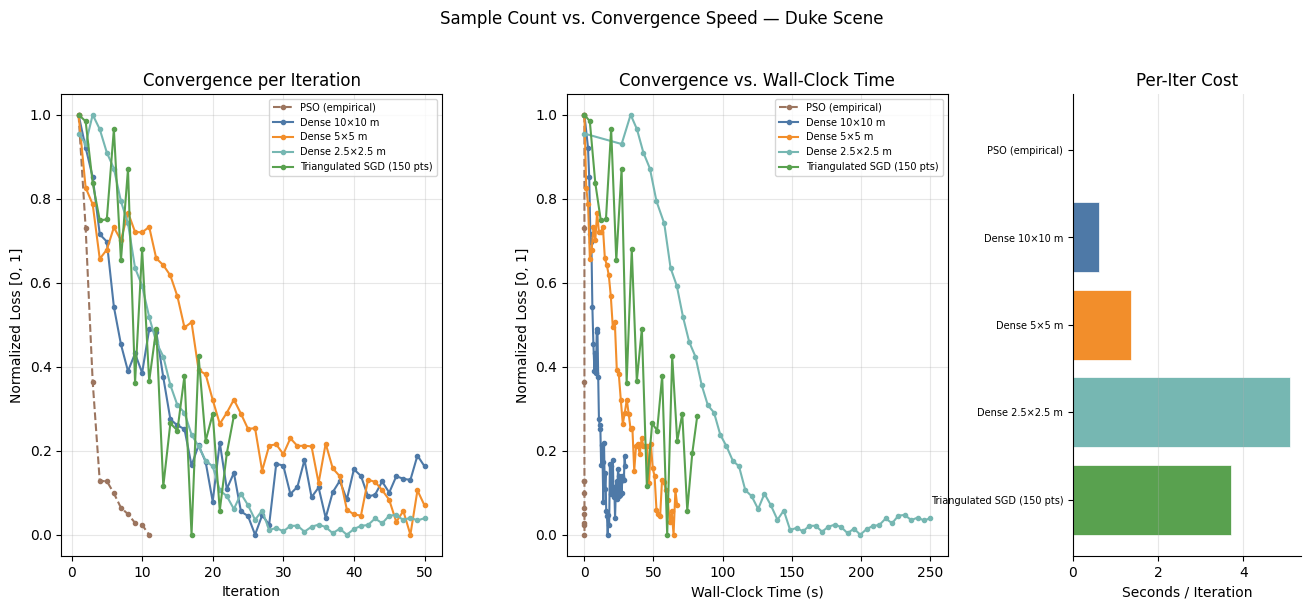


Method                           Receivers   s / iter   iters / min
────────────────────────────────────────────────────────────────────
  PSO (empirical)                      300       0.01       11647.6
  Dense 10×10 m                        539       0.60          99.5
  Dense 5×5 m                         2165       1.37          43.8
  Dense 2.5×2.5 m                     8639       5.10          11.8
  Triangulated SGD (150 pts)             —       3.71          16.2


In [ ]:
# ── SCALING SUMMARY PLOT ──────────────────────────────────────────────────────
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(16, 6))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.38, width_ratios=[2, 2, 1.2])

ax_iter = fig.add_subplot(gs[0])
ax_time = fig.add_subplot(gs[1])
ax_cost = fig.add_subplot(gs[2])

_colors = {
    "pso":              "#9c755f",
    "dense_10m":        "#4e79a7",
    "dense_5m":         "#f28e2b",
    "dense_2.5m":       "#76b7b2",
    "triangulated_150": "#59a14f",
}
_labels = {
    "pso":              "PSO (empirical)",
    "dense_10m":        "Dense 10×10 m",
    "dense_5m":         "Dense 5×5 m",
    "dense_2.5m":       "Dense 2.5×2.5 m",
    "triangulated_150": "Triangulated SGD (150 pts)",
}

_cost_rows = []  # (label, n_rx, mean_s_per_iter, color)

for key in ["pso", "dense_10m", "dense_5m", "dense_2.5m", "triangulated_150"]:
    res = scaling_results.get(key)
    if res is None:
        continue
    joint  = res["joint"]
    loss   = np.array(joint["loss_history"], dtype=float)
    times  = np.array(joint.get("iter_time_history", []), dtype=float)

    lo, hi    = loss.min(), loss.max()
    norm_loss = (loss - lo) / (hi - lo) if hi > lo else np.zeros_like(loss)
    iters     = np.arange(1, len(loss) + 1)
    cum_time  = np.concatenate([[0.0], np.cumsum(times)])[:len(loss)]

    color = _colors[key]
    label = _labels[key]
    ls    = "--" if key == "pso" else "-"

    ax_iter.plot(iters, norm_loss, label=label, color=color, linewidth=1.5,
                 linestyle=ls, marker='o', markersize=3)
    ax_time.plot(cum_time, norm_loss, label=label, color=color, linewidth=1.5,
                 linestyle=ls, marker='o', markersize=3)

    n_rx   = joint.get("n_receivers", joint.get("n_eval_pts", "—"))
    mean_t = float(np.mean(times)) if len(times) > 0 else float("nan")
    _cost_rows.append((label, n_rx, mean_t, color))

ax_iter.set_xlabel("Iteration")
ax_iter.set_ylabel("Normalized Loss [0, 1]")
ax_iter.set_title("Convergence per Iteration")
ax_iter.legend(fontsize=7, loc="upper right")
ax_iter.grid(True, alpha=0.3)

ax_time.set_xlabel("Wall-Clock Time (s)")
ax_time.set_ylabel("Normalized Loss [0, 1]")
ax_time.set_title("Convergence vs. Wall-Clock Time")
ax_time.legend(fontsize=7, loc="upper right")
ax_time.grid(True, alpha=0.3)

# Cost bar chart: seconds per iteration
_bar_labels = [r[0] for r in _cost_rows]
_bar_times  = [r[2] for r in _cost_rows]
_bar_colors = [r[3] for r in _cost_rows]
_y = np.arange(len(_bar_labels))
ax_cost.barh(_y, _bar_times, color=_bar_colors, edgecolor="white", linewidth=0.5)
ax_cost.set_yticks(_y)
ax_cost.set_yticklabels(_bar_labels, fontsize=7)
ax_cost.set_xlabel("Seconds / Iteration")
ax_cost.set_title("Per-Iter Cost")
ax_cost.invert_yaxis()
ax_cost.grid(True, axis="x", alpha=0.3)
ax_cost.spines[["top", "right"]].set_visible(False)

plt.suptitle("Sample Count vs. Convergence Speed — Duke Scene", y=1.02)
plt.tight_layout()
plt.show()

print(f"\n{'Method':<30}  {'Receivers':>10}  {'s / iter':>9}  {'iters / min':>12}")
print("─" * 68)
for label, n_rx, mean_t, _ in _cost_rows:
    ipm = 60.0 / mean_t if mean_t > 0 else float("nan")
    print(f"  {label:<28}  {str(n_rx):>10}  {mean_t:>9.2f}  {ipm:>12.1f}")


BEFORE / AFTER COMPARISON
  gnb1:
    Initial:   Az=188.9°, El=-7.7°, pos=(-10.9, 329.5)
    Optimised: Az=191.3°, El=-10.7°, pos=(-60.6, 329.7)
  gnb2:
    Initial:   Az=347.9°, El=-8.4°, pos=(-272.4, -63.1)
    Optimised: Az=0.0°, El=0.0°, pos=(-261.0, -97.9)

Computing RadioMap for initial configuration...
Computing RadioMap for optimized configuration...

RESULTS
  gnb1  (1068 non-building zone cells):
    Coverage:      94.5%  →   99.0%  (+4.5 pp)
    RSRP mean:     -62.2 dBm  →    -53.6 dBm  (+8.5 dB)
    RSRP median:   -56.3 dBm  →    -52.9 dBm  (+3.4 dB)
    RSRP p10:      -86.8 dBm  →    -74.5 dBm  (+12.3 dB)
    RSRP p90:      -39.6 dBm  →    -35.0 dBm
    SIR mean:      +12.0 dB   →    +16.2 dB   (+4.2 dB)  [covered cells]
    SIR median:    +14.3 dB   →    +17.1 dB   (+2.7 dB)  [covered cells]
    SIR p10:       -11.0 dB   →     -6.0 dB   (+5.0 dB)  [covered cells]
    SIR p90:       +29.8 dB   →    +34.9 dB   [covered cells]
  gnb2  (1097 non-building zone cells):
    Cov

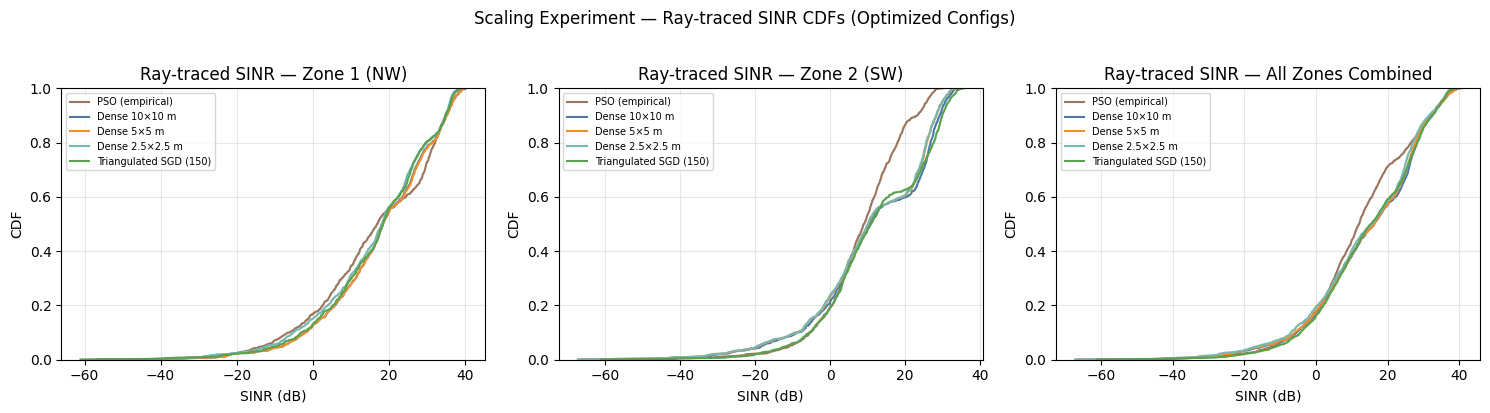

In [ ]:
# ── SCALING EXPERIMENT — RAY-TRACED SINR CDFs ─────────────────────────────────
_scale_sinr_entries = [
    ("PSO (empirical)",         "pso",              tx_configs_2,      "#9c755f"),
    ("Dense 10×10 m",           "dense_10m",        tx_configs_2,      "#4e79a7"),
    ("Dense 5×5 m",             "dense_5m",         tx_configs_2,      "#f28e2b"),
    ("Dense 2.5×2.5 m",         "dense_2.5m",       tx_configs_2,      "#76b7b2"),
    ("Triangulated SGD (150)",  "triangulated_150", _tx_configs_scale, "#59a14f"),
]

_scale_sinr_stats = {}
for _label, _key, _cfgs, _color in _scale_sinr_entries:
    _r = scaling_results.get(_key)
    if _r is None:
        continue
    _, _stats = compare_multi_tx_performance(
        scene=scene,
        tx_configs=_cfgs,
        multi_result=_r,
        map_config=MAP_CONFIG,
        zone_masks=[zone_mask1, zone_mask2],
        noise_power=NOISE_POWER,
        samples_per_tx=int(1e7),
        fig=False,
    )
    _scale_sinr_stats[_label] = (_stats, _color)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
_zone_specs = [
    (TX1_NAME, "Zone 1 (NW)"),
    (TX2_NAME, "Zone 2 (SW)"),
    (None,     "All Zones Combined"),
]

for ax_i, (tx_name, zone_label) in enumerate(_zone_specs):
    ax = axes[ax_i]
    for _label, (_stats, _color) in _scale_sinr_stats.items():
        if tx_name is not None:
            sinr_vals = np.array(_stats[tx_name]["optimized"]["sir_values_db"])
        else:
            sinr_vals = np.concatenate([
                np.array(_stats[TX1_NAME]["optimized"]["sir_values_db"]),
                np.array(_stats[TX2_NAME]["optimized"]["sir_values_db"]),
            ])
        sorted_v = np.sort(sinr_vals)
        cdf = np.arange(1, len(sorted_v) + 1) / len(sorted_v)
        ax.plot(sorted_v, cdf, label=_label, color=_color, linewidth=1.5)
    ax.set_xlabel("SINR (dB)")
    ax.set_ylabel("CDF")
    ax.set_title(f"Ray-traced SINR — {zone_label}")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1)

plt.suptitle("Scaling Experiment — Ray-traced SINR CDFs (Optimized Configs)", y=1.02)
plt.tight_layout()
plt.show()